# 🧠 Análisis Exploratorio del Dataset: Stroke Prediction
**Objetivo:** Explorar los datos crudos, identificar inconsistencias ocultas (como los valores "Unknown" en el estado de tabaquismo) y definir un flujo de limpieza y transformación riguroso para predecir accidentes cerebrovasculares, que luego llevaremos a nuestro entorno local en VS Code para construir el pipeline [1, 2].

**Diccionario de Variables Clave:**
* `id`: Identificador único del paciente.
* `gender`: Género del paciente ("Male", "Female" u "Other").
* `age`: Edad del paciente.
* `hypertension`: ¿El paciente tiene hipertensión? (0 = no, 1 = sí).
* `heart_disease`: ¿El paciente tiene alguna enfermedad cardíaca? (0 = no, 1 = sí).
* `ever_married`: ¿El paciente se ha casado alguna vez? ("No" o "Yes").
* `work_type`: Tipo de empleo ("children", "Govt_jov", "Never_worked", "Private" o "Self-employed").
* `Residence_type`: Tipo de entorno de residencia ("Rural" o "Urban").
* `avg_glucose_level`: Nivel promedio de glucosa en la sangre.
* `bmi`: Índice de masa corporal (Body Mass Index).
* `smoking_status`: Condición de tabaquismo ("formerly smoked", "never smoked", "smokes" o "Unknown"*).
* `stroke`: **Variable Objetivo.** ¿El paciente tuvo un accidente cerebrovascular? (1 = sí, 0 = no).

El ataque ataque cerebrovascular (ACV), o ictus, es una emergencia médica que ocurre cuando el flujo sanguíneo al cerebro se detiene (isquémico) o un vaso sanguíneo se rompe (hemorrágico), matando células cerebrales por falta de oxígeno. según la Organización Mundial de la Salud (OMS), el ictus es *la segunda causa principal de muerte* a nivel mundial, responsable de aproximadamente el 11 % del total de fallecimientos.

Este conjunto de datos se utiliza para predecir la probabilidad de que un paciente sufra un accidente cerebrovascular, basándose en parámetros como el sexo, la edad, diversas enfermedades y el tabaquismo. Cada fila de los datos proporciona información relevante sobre el paciente.

---

## 1. Primer vistazo al DataSet.

Se realiza importación de dependencias.

In [13]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Se trae el dataset en cuestión.

In [14]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
base_dir = Path('..').resolve()
plots_dir = base_dir / 'results' / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)

# Cargamos el dataset de la carpeta data/raw/
df = pd.read_csv("../data/raw/healthcare-dataset-stroke-data.csv")
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Estandarización de Nulos.

Antes de realizar el conteo total de valores faltantes, tales como 'Unknown' o 'NaN', es necesario aplicar una transformación que permita estandarizar dichos campos. Por ejemplo, si en una columna tenemos un valor oculto de tipo 'na' y en otra 'unknown' (en minúsculas), se debe conservar una única identificación para el valor nulo. Esto es crucial tanto para la precisión del análisis matemático como para su correcta exposición gráfica.

In [15]:
# 1. Definimos los valores basura
valores_basura = ['unknown', 'Unknown', 'UNKNOWN', 'na', 'NA']

Se reemplaza todo lo que pueda ser un valor faltante por un tipo de dato "NaN" de la libreria Numpy, lo cual se ajusta a un estandar para hacer este análisis exploratorio.

In [16]:
df = df.replace(valores_basura, np.nan)

In [17]:
print("--- Conteo de 'NaN' por columna ---")
# Suma todos los NaN
count_nan = df.isnull().sum()

print(count_nan[count_nan > 0].sort_values(ascending=False))

--- Conteo de 'NaN' por columna ---
smoking_status    1544
bmi                201
dtype: int64


Se crea un mapa de calor para visualización de datos.

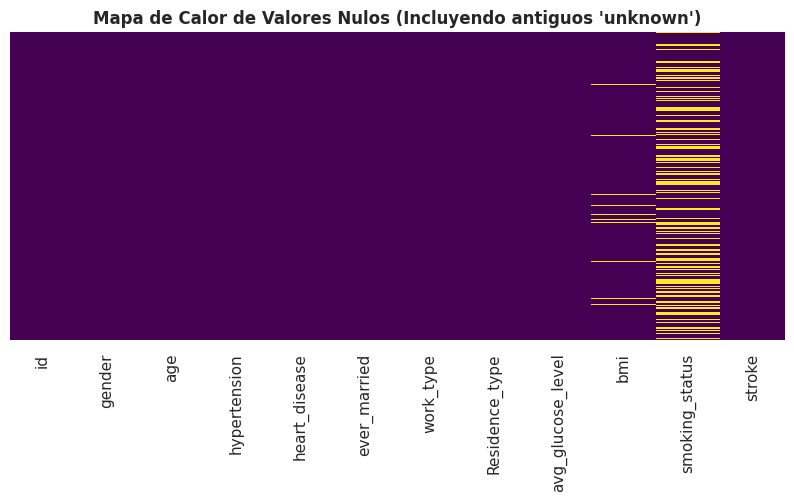

In [18]:
# Mapa de Calor Optimizado para valores nulos
plt.figure(figsize=(10, 4))

# Usamos df.isnull() para que evalúe si es True (nulo) o False (dato válido)
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)

plt.title("Mapa de Calor de Valores Nulos (Incluyendo antiguos 'unknown')", fontweight='bold')

# Guardar el gráfico
plt.savefig(plots_dir / 'null_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


Podemos darnos cuenta que la variable `smoking_status` posee una gran cantidad de valores `NaN`, por lo que se evalua si mantener dicha columna es factible o no basado en la proporción.

## 3. Variable Objetivo: `stroke`
**¿El paciente sufrió un ataque cerebrovascular?**

En nuestro conjunto de datos, la variable a predecir (target) es `stroke`. Es una variable de clasificación binaria que indica el historial médico del paciente respecto a esta afección:
* **`1`**: El paciente **sí** sufrió un ataque cerebrovascular.
* **`0`**: El paciente **no** sufrió un ataque cerebrovascular.

Realizaremos un gráfico que nos permitira analizar la proporción de esta variable.

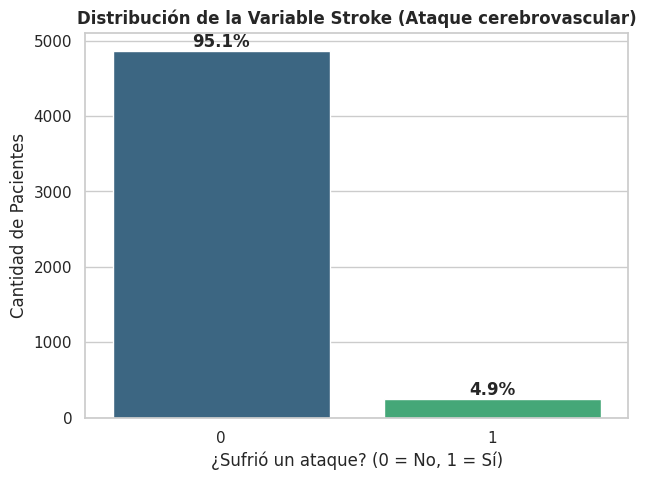

In [19]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='stroke', palette='viridis')
plt.title('Distribución de la Variable Stroke (Ataque cerebrovascular)', fontweight='bold')
plt.ylabel('Cantidad de Pacientes')
plt.xlabel('¿Sufrió un ataque? (0 = No, 1 = Sí)')

# Agregar los porcentajes arriba de las barras
total = len(df)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(porcentaje, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.show()

## 4. EDA

Para agilizar nuestro Análisis Exploratorio de Datos (EDA) y evitar la repetición de código, hemos diseñado una función automatizada llamada `plot_numeric_distributions`. 

En lugar de crear un gráfico individual para cada variable, esta función escanea el conjunto de datos, identifica todas las columnas numéricas relevantes y genera una cuadrícula (grid) de histogramas de densidad. Al superponer la distribución de los datos según la variable objetivo (`stroke`), podemos identificar de un vistazo qué factores (como la edad o el nivel de glucosa) tienen mayor impacto en los ataques cerebrovasculares.

Generando distribuciones numéricas...


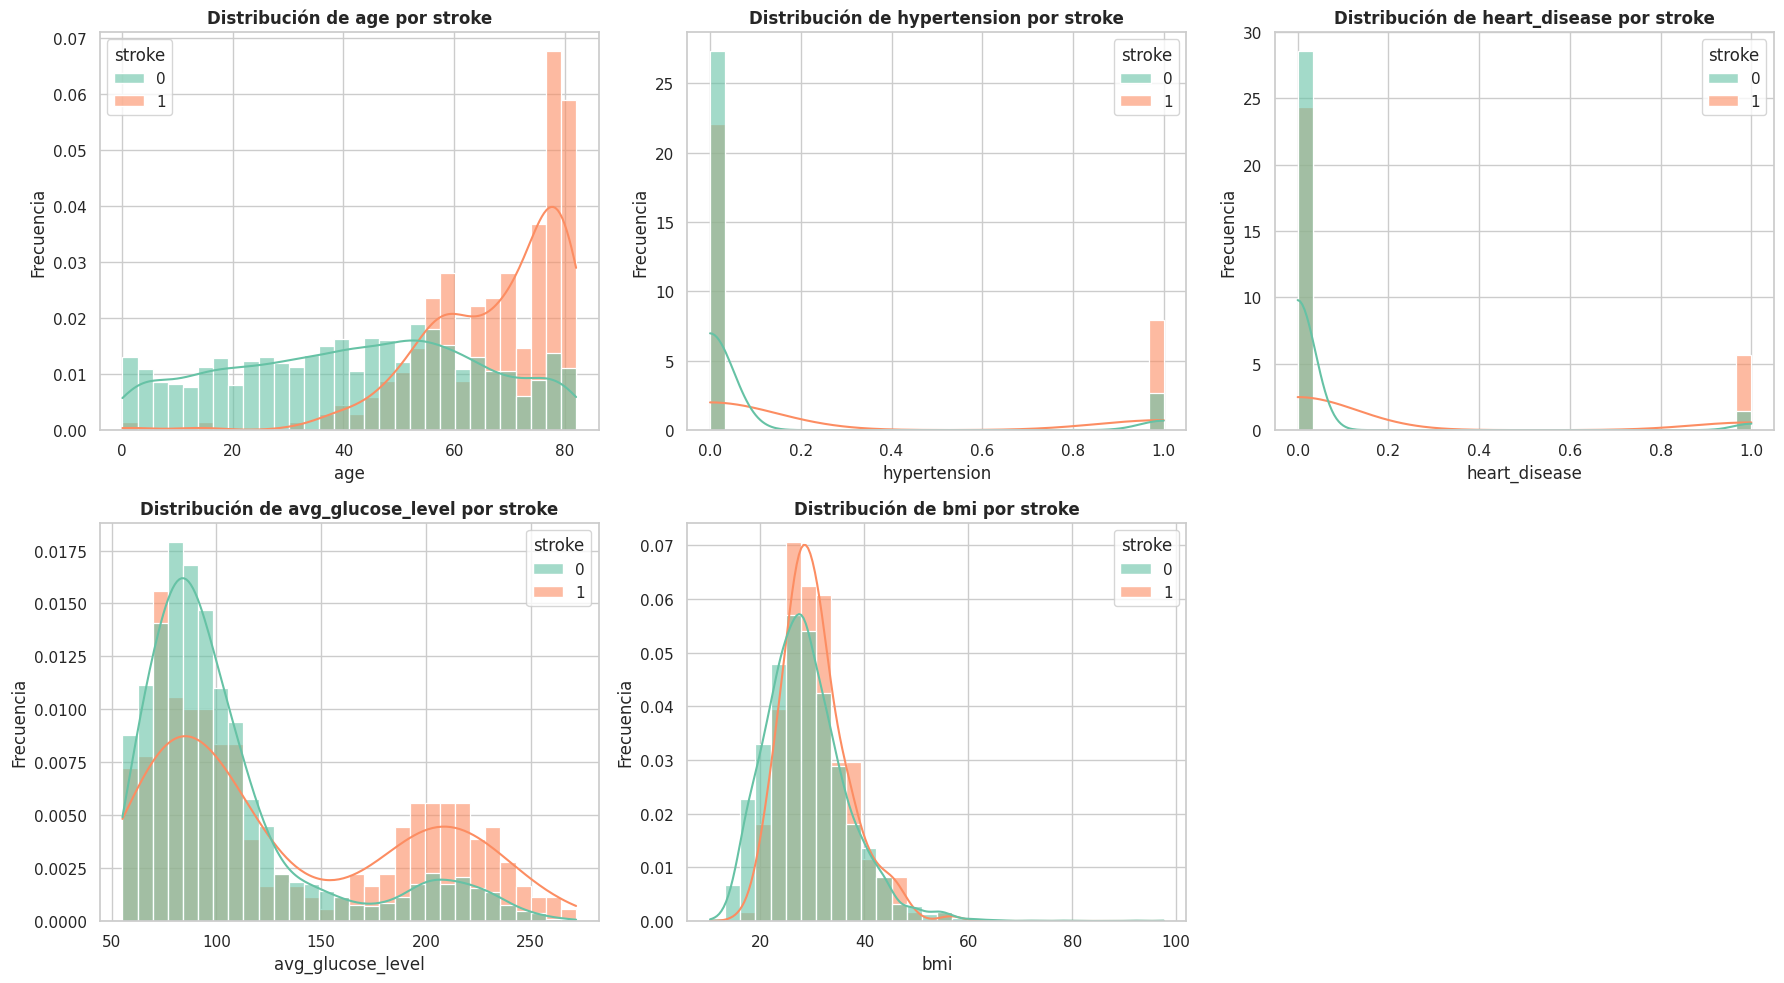


Generando frecuencias categóricas...


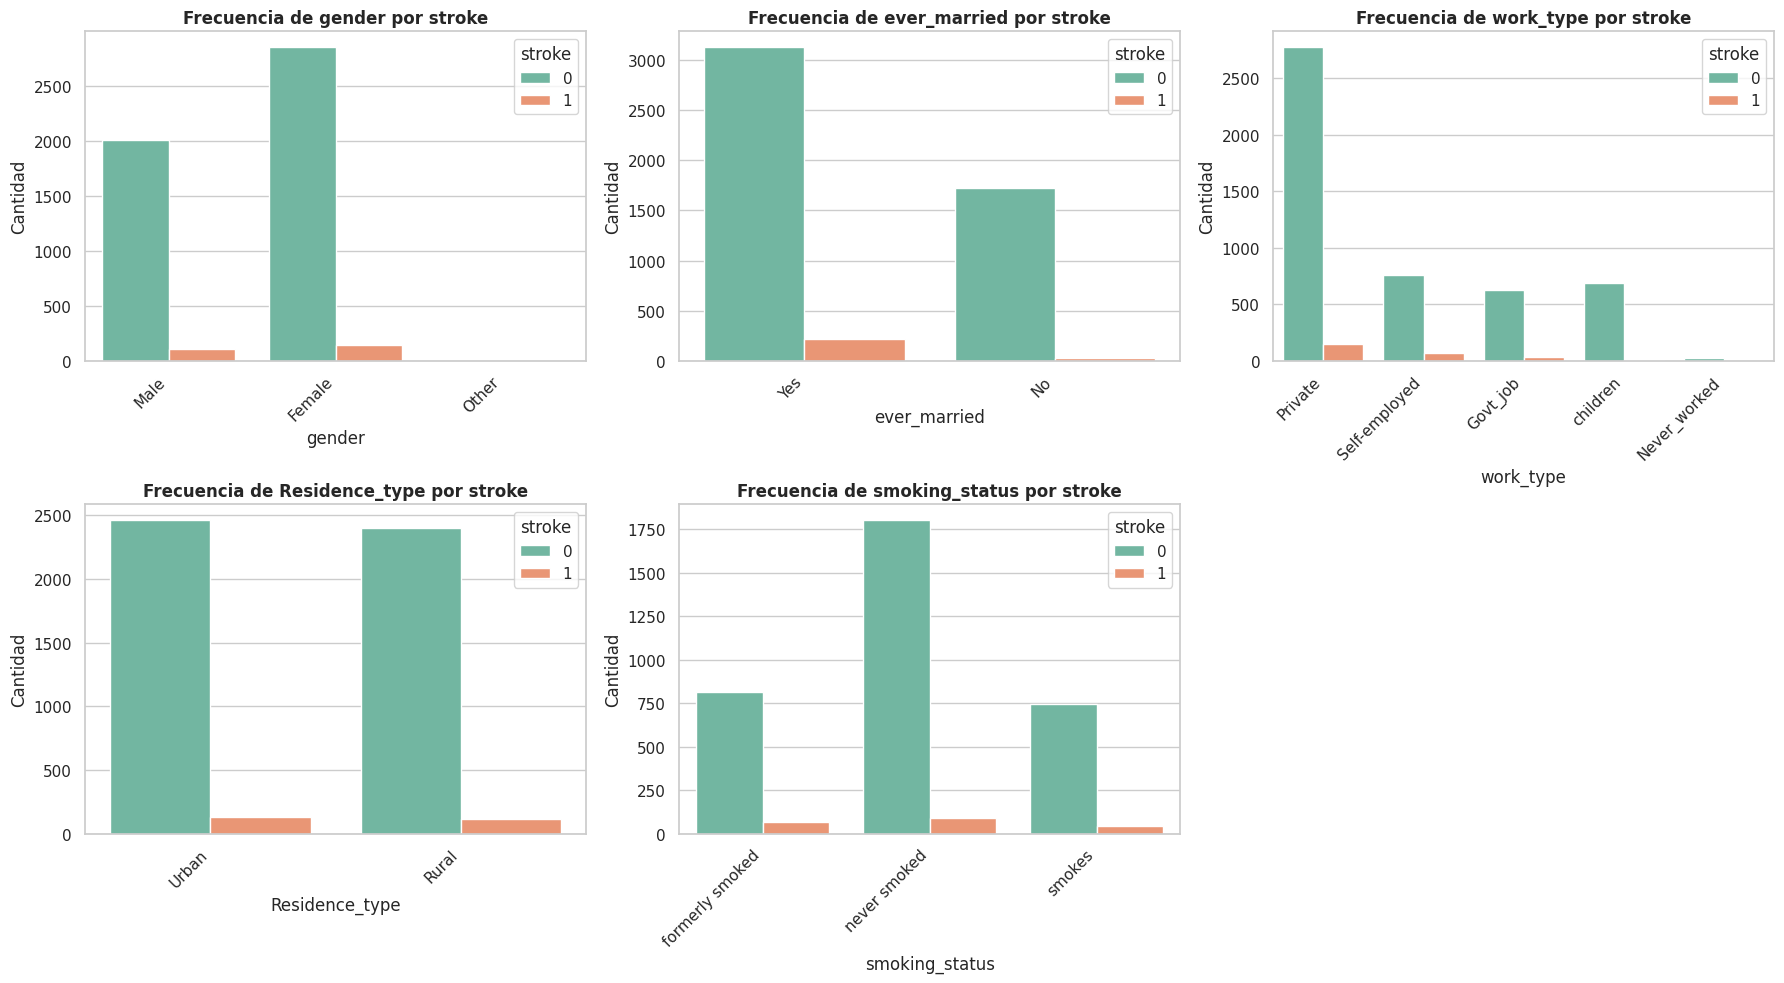

In [20]:
def plot_numeric_distributions(df, target_col):
    """Genera histogramas superpuestos para variables numéricas."""
    # 1. Detectar variables numéricas
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    
    # 2. ADAPTACIÓN: Excluimos 'id' porque no aporta valor predictivo y el target
    num_cols = [c for c in num_cols if c != target_col and c != 'id']

    n_cols = 3
    n_rows = int(np.ceil(len(num_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        # Histograma separado por colores según si tuvo ataque o no
        sns.histplot(data=df, x=col, hue=target_col, kde=True, ax=axes[i],
                     bins=30, alpha=0.6, stat='density', common_norm=False, palette='Set2')
        axes[i].set_title(f'Distribución de {col} por {target_col}', fontweight='bold')
        axes[i].set_ylabel('Frecuencia')

    # Eliminar subplots vacíos si los hay
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    
    # 3. ADAPTACIÓN OBLIGATORIA: Guardar gráfico en la carpeta correcta
    plt.savefig(plots_dir / 'distribuciones_numericas.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_categorical_counts(df, target_col):
    """Genera gráficos de barras para variables categóricas."""
    # 1. Detectar variables categóricas (textos)
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    cat_cols = [c for c in cat_cols if c != target_col]

    n_cols = 3
    n_rows = int(np.ceil(len(cat_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        sns.countplot(data=df, x=col, hue=target_col, ax=axes[i], palette="Set2")
        axes[i].set_title(f'Frecuencia de {col} por {target_col}', fontweight='bold')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
        axes[i].set_ylabel('Cantidad')

    # Eliminar subplots vacíos si los hay
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    
    # 3. ADAPTACIÓN OBLIGATORIA: Guardar gráfico en la carpeta correcta
    plt.savefig(plots_dir / 'frecuencias_categoricas.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- EJECUCIÓN DEL CÓDIGO ---

print("Generando distribuciones numéricas...")
# Apuntamos a nuestra variable objetivo real: 'stroke'
plot_numeric_distributions(df, target_col='stroke')

print("\nGenerando frecuencias categóricas...")
# Apuntamos a nuestra variable objetivo real: 'stroke'
plot_categorical_counts(df, target_col='stroke')

## 6. PCA y K-Means

En esta sección preparamos una versión numérica del dataset, aplicamos `StandardScaler`, reducimos dimensionalidad con `PCA` y evaluamos `K-Means` para valores de `k` entre 2 y 10 usando el Método del Codo y el Índice de Silueta.

In [21]:
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import silhouette_score

In [22]:
# Cargamos el dataset desde la raíz del proyecto
base_dir = Path('..').resolve()
data_path = base_dir / 'data' / 'raw' / 'healthcare-dataset-stroke-data.csv'
plots_dir = base_dir / 'results' / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)
print(f'Dataset cargado desde: {data_path}')
print(f'Dimensiones: {df.shape}')

Dataset cargado desde: /home/tomy/Downloads/cdd_ev2/mi_proyecto/data/raw/healthcare-dataset-stroke-data.csv
Dimensiones: (5110, 12)


In [23]:
# Preprocesamiento para clustering: eliminamos la variable objetivo y el identificador
cluster_df = df.drop(columns=['stroke', 'id'], errors='ignore').copy()

numeric_features = cluster_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = cluster_df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

X_prepared = preprocessor.fit_transform(cluster_df)
print(f'Matriz preparada para clustering: {X_prepared.shape}')

Matriz preparada para clustering: (5110, 21)


In [24]:
# PCA para análisis visual y reducción de dimensionalidad
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_prepared)

explained = pca.explained_variance_ratio_.sum()
print(f'Varianza explicada por los 2 primeros componentes: {explained:.3f}')

Varianza explicada por los 2 primeros componentes: 0.395


In [25]:
k_values = list(range(2, 11))
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

results = pd.DataFrame({
    'k': k_values,
    'inertia': inertias,
    'silhouette': silhouette_scores,
})
results

,k,inertia,silhouette
0,2,9131.309270,0.401901
1,3,5000.199522,0.489656
2,4,3215.208753,0.478780
3,5,2400.656251,0.424173
4,6,2006.605437,0.403311
5,7,1754.355470,0.400713
6,8,1543.910011,0.387756
7,9,1367.713657,0.383441
8,10,1237.625475,0.383382


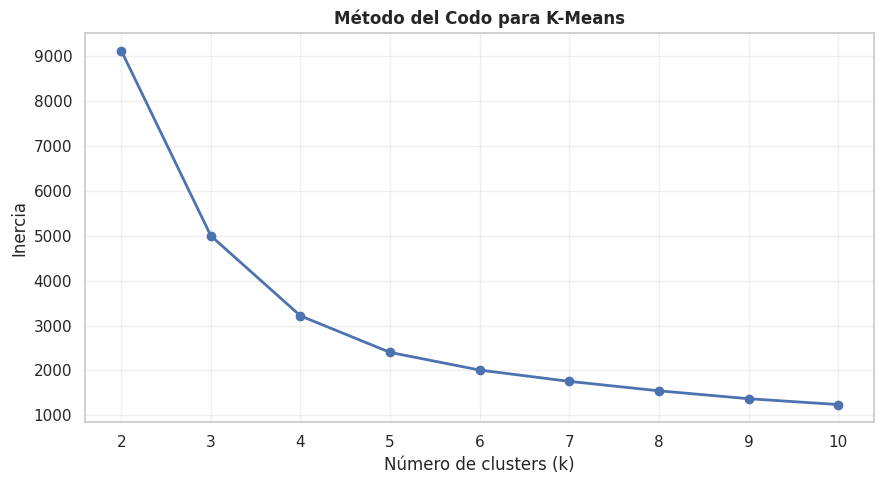

In [26]:
# Método del Codo
plt.figure(figsize=(9, 5))
plt.plot(results['k'], results['inertia'], marker='o', linewidth=2)
plt.xticks(results['k'])
plt.title('Método del Codo para K-Means', fontweight='bold')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / 'kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

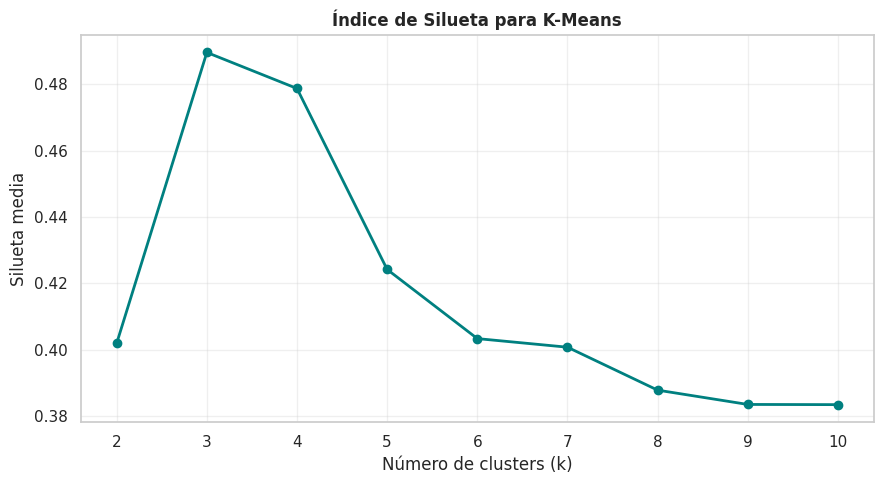

In [27]:
# Índice de Silueta
plt.figure(figsize=(9, 5))
plt.plot(results['k'], results['silhouette'], marker='o', linewidth=2, color='teal')
plt.xticks(results['k'])
plt.title('Índice de Silueta para K-Means', fontweight='bold')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silueta media')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / 'kmeans_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

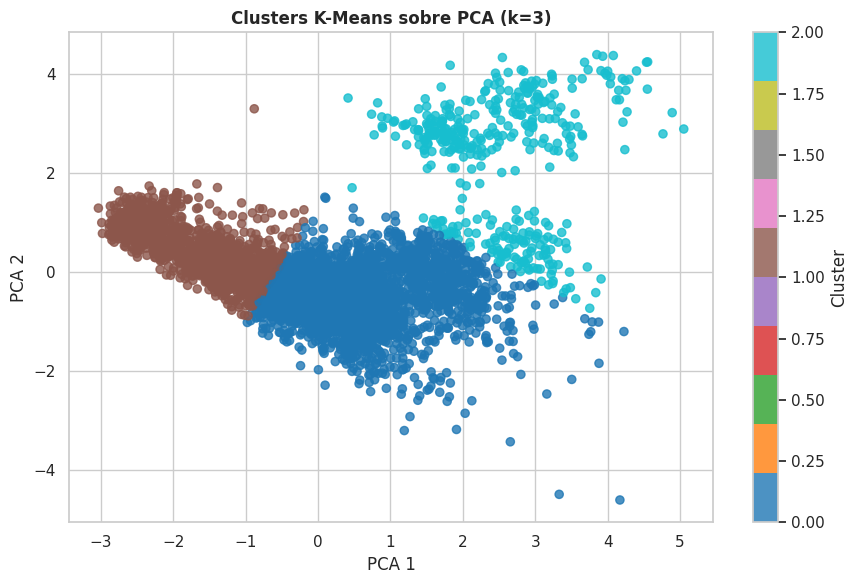

In [28]:
# Ajuste final de K-Means para una visualización 2D sobre PCA
best_k = int(results.sort_values(['silhouette', 'inertia'], ascending=[False, True]).iloc[0]['k'])
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_pca)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.8, s=35)
plt.title(f'Clusters K-Means sobre PCA (k={best_k})', fontweight='bold')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig(plots_dir / 'kmeans_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()